# Stage 5 — Robustness: Verdict

**Notebook:** `notebooks/06_stage5_robustness.ipynb`

**H5:** The dominance of attractiveness is robust across subsamples, wave exclusions, model specifications, and alternative link functions.

Stage 5 verdict: *attr dominance is stable — not driven by sample choice, wave artifacts, model specification, or standard-error convention.*

In [1]:
import os
from pathlib import Path

def _project_root(marker="README.md"):
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / marker).exists():
            return p
    raise FileNotFoundError("Project root not found")

os.chdir(_project_root())
print("Working directory:", Path.cwd())

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)

Path("tables").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

NON_ATTR_TRAITS  = ["sinc", "intel", "fun", "amb", "shar"]
ALL_SIX          = ["attr"] + NON_ATTR_TRAITS
formula_pooled   = "dec ~ attr + sinc + intel + fun + amb + shar"
formula_fe_panel = "dec ~ attr + sinc + intel + fun + amb + shar + EntityEffects"
CI_MULT          = 1.96

def _rank_attr(params):
    """Rank attr among ALL_SIX by absolute coefficient value; 1 = largest."""
    abs_vals = {t: abs(float(params[t])) for t in ALL_SIX}
    return sorted(abs_vals.values(), reverse=True).index(abs_vals["attr"]) + 1

print("Setup complete.")

Working directory: /Users/chen/Study/UCB/STAT230a/speed-dating-halo
Setup complete.


In [2]:
# ── Load main data (excl Wave 6-9), remove singletons ──────────────────
df_raw = pd.read_parquet("data/clean/cleaned.parquet")
iid_counts     = df_raw.groupby("iid").size()
singleton_iids = iid_counts[iid_counts == 1].index
df = df_raw[~df_raw["iid"].isin(singleton_iids)].copy()
print(f"Main data: {len(df):,} rows  |  {df['iid'].nunique()} participants")
print(f"Waves: {sorted(df['wave'].unique())}")

# ── Load Stage 1 & 3 baseline numbers ───────────────────────────────────
t01 = pd.read_csv("tables/table01_baseline_lpm.csv").set_index("variable")
t03 = pd.read_csv("tables/table03_pooled_vs_fe.csv").set_index("variable")

baseline_coef    = float(t01.loc["attr", "coef"])
baseline_se      = float(t01.loc["attr", "std_err_clustered"])
baseline_pval    = float(t01.loc["attr", "p_value"])
baseline_ci_low  = float(t01.loc["attr", "ci_lower"])
baseline_ci_high = float(t01.loc["attr", "ci_upper"])
baseline_N       = int(t01.loc["attr", "n_obs"])

fe_coef  = float(t03.loc["attr", "fe_coef"])
fe_se    = float(t03.loc["attr", "fe_se"])
fe_pval  = float(t03.loc["attr", "fe_pvalue"])

print(f"\nBaseline LPM  (Stage 1): attr={baseline_coef:.4f}  SE={baseline_se:.4f}  p={baseline_pval:.2e}  N={baseline_N}")
print(f"Participant FE (Stage 3): attr={fe_coef:.4f}  SE={fe_se:.4f}  p={fe_pval:.2e}  N={len(df)}")

def overlaps_baseline(ci_low, ci_high):
    return bool((ci_low <= baseline_ci_high) and (ci_high >= baseline_ci_low))

def make_row(spec, model_type, sample, N, coef, se, pval, rank, notes=""):
    ci_low  = coef - CI_MULT * se
    ci_high = coef + CI_MULT * se
    return {
        "specification":        spec,
        "model_type":           model_type,
        "sample":               sample,
        "N":                    int(N),
        "attr_coef_or_AME":     round(coef,  6),
        "attr_SE":              round(se,    6),
        "attr_pvalue":          round(pval,  6),
        "attr_rank":            int(rank),
        "is_attr_largest":      rank == 1,
        "is_attr_top2":         rank <= 2,
        "CI_low":               round(ci_low,  6),
        "CI_high":              round(ci_high, 6),
        "overlaps_baseline_CI": overlaps_baseline(ci_low, ci_high),
        "notes":                notes,
    }

# Pre-build baseline and FE rows for the summary table (Part F)
baseline_coefs_all = {t: float(t01.loc[t, "coef"]) for t in ALL_SIX}
fe_coefs_all       = {t: float(t03.loc[t, "fe_coef"]) for t in ALL_SIX}

baseline_row = make_row(
    "Baseline LPM (pooled)", "Pooled LPM", "Full", baseline_N,
    baseline_coef, baseline_se, baseline_pval,
    _rank_attr(baseline_coefs_all),
    notes="From Stage 1 table01_baseline_lpm.csv",
)
fe_row = make_row(
    "LPM + Participant FE", "FE LPM", "Full", len(df),
    fe_coef, fe_se, fe_pval,
    _rank_attr(fe_coefs_all),
    notes="From Stage 3 table03_pooled_vs_fe.csv; clustered by participant",
)

Main data: 5,734 rows  |  434 participants
Waves: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]

Baseline LPM  (Stage 1): attr=0.0865  SE=0.0054  p=0.00e+00  N=5742
Participant FE (Stage 3): attr=0.0902  SE=0.0042  p=0.00e+00  N=5734


## Part A — Subsample Robustness

Each subsample runs both models:
1. **Pooled LPM** with iid-clustered SE
2. **Participant FE LPM** via `PanelOLS + EntityEffects` (same as Stage 3)

Subsamples: Male, Female, Excl Wave 5 (undergrad), Excl Wave 12 (50% quota).

In [3]:
subsamples = {
    "Male":         df[df["gender"] == 1].copy(),
    "Female":       df[df["gender"] == 0].copy(),
    "Excl Wave 5":  df[df["wave"] != 5].copy(),
    "Excl Wave 12": df[df["wave"] != 12].copy(),
}

results_a = []
for name, sub_df in subsamples.items():
    # Drop singletons within subsample
    cnt    = sub_df.groupby("iid").size()
    sub_df = sub_df[sub_df["iid"].isin(cnt[cnt > 1].index)].copy()

    # Pooled LPM
    pooled_mod = smf.ols(formula_pooled, data=sub_df).fit(
        cov_type="cluster", cov_kwds={"groups": sub_df["iid"].values})

    # Participant FE — PanelOLS + EntityEffects, consistent with Stage 3
    panel_df = sub_df.set_index(["iid", "order"])
    fe_mod = PanelOLS.from_formula(formula_fe_panel, data=panel_df).fit(
        cov_type="clustered", cluster_entity=True)

    for model_type, mod, is_panel in [
        ("Pooled LPM", pooled_mod, False),
        ("FE LPM",     fe_mod,     True),
    ]:
        coef = float(mod.params["attr"])
        se   = float(mod.std_errors["attr"] if is_panel else mod.bse["attr"])
        pval = float(mod.pvalues["attr"])
        rank = _rank_attr({t: mod.params[t] for t in ALL_SIX})
        results_a.append(make_row(
            f"{name} — {model_type}", model_type, name,
            int(mod.nobs), coef, se, pval, rank,
        ))
        print(f"{name} — {model_type}: N={int(mod.nobs):,}  "
              f"attr={coef:.4f}  SE={se:.4f}  p={pval:.2e}  rank={rank}")

df_a = pd.DataFrame(results_a)
print()
print(df_a[["specification", "N", "attr_coef_or_AME", "attr_SE",
            "attr_rank", "is_attr_top2", "overlaps_baseline_CI"]].to_string(index=False))

Male — Pooled LPM: N=2,884  attr=0.1092  SE=0.0070  p=2.02e-55  rank=1
Male — FE LPM: N=2,884  attr=0.1028  SE=0.0063  p=0.00e+00  rank=1
Female — Pooled LPM: N=2,850  attr=0.0638  SE=0.0076  p=5.07e-17  rank=1
Female — FE LPM: N=2,850  attr=0.0775  SE=0.0053  p=0.00e+00  rank=1
Excl Wave 5 — Pooled LPM: N=5,569  attr=0.0861  SE=0.0056  p=1.47e-53  rank=1
Excl Wave 5 — FE LPM: N=5,569  attr=0.0907  SE=0.0043  p=0.00e+00  rank=1
Excl Wave 12 — Pooled LPM: N=5,391  attr=0.0856  SE=0.0057  p=8.97e-52  rank=1
Excl Wave 12 — FE LPM: N=5,391  attr=0.0891  SE=0.0044  p=0.00e+00  rank=1

            specification    N  attr_coef_or_AME  attr_SE  attr_rank  is_attr_top2  overlaps_baseline_CI
        Male — Pooled LPM 2884            0.1092   0.0070          1          True                  True
            Male — FE LPM 2884            0.1028   0.0063          1          True                  True
      Female — Pooled LPM 2850            0.0638   0.0076          1          True                

## Part B — Wave 6–9 Sensitivity

**B1 (revealed):** Include Waves 6–9 in the pooled LPM. Checks whether adding the independent-rating waves changes attr dominance.

**B2 (stated):** Normalize Wave 6–9 stated preferences (1–10 → %) then aggregate to person-level before computing means. Confirms the stated-vs-revealed discrepancy from Stage 1/2 persists.

In [4]:
# ── B1: Revealed-preference robustness with Waves 6-9 ──────────────────
df_all_raw  = pd.read_parquet("data/clean/cleaned_all_waves.parquet")
cnt_all     = df_all_raw.groupby("iid").size()
df_all      = df_all_raw[~df_all_raw["iid"].isin(cnt_all[cnt_all == 1].index)].copy()
df_all_model = df_all.dropna(subset=["dec"] + ALL_SIX).copy()

print(f"All-waves model sample: {len(df_all_model):,} rows  |  "
      f"{df_all_model['iid'].nunique()} participants")
print(f"Waves included: {sorted(df_all_model['wave'].unique())}")

mod_all = smf.ols(formula_pooled, data=df_all_model).fit(
    cov_type="cluster", cov_kwds={"groups": df_all_model["iid"].values})

b1_coef = float(mod_all.params["attr"])
b1_se   = float(mod_all.bse["attr"])
b1_pval = float(mod_all.pvalues["attr"])
b1_rank = _rank_attr({t: mod_all.params[t] for t in ALL_SIX})

print(f"\nIncl Wave 6-9 (revealed): attr={b1_coef:.4f}  SE={b1_se:.4f}  "
      f"p={b1_pval:.2e}  rank={b1_rank}")
print("\nAll six traits (incl W6-9):")
for t in ALL_SIX:
    print(f"  {t:8s}: {mod_all.params[t]:+.4f}  (SE={mod_all.bse[t]:.4f})")

All-waves model sample: 7,022 rows  |  528 participants
Waves included: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]

Incl Wave 6-9 (revealed): attr=0.0898  SE=0.0049  p=9.80e-76  rank=1

All six traits (incl W6-9):
  attr    : +0.0898  (SE=0.0049)
  sinc    : -0.0174  (SE=0.0060)
  intel   : +0.0060  (SE=0.0062)
  fun     : +0.0381  (SE=0.0048)
  amb     : -0.0225  (SE=0.0047)
  shar    : +0.0431  (SE=0.0047)


In [5]:
# ── B2: Stated-preference normalization (Wave 6-9 only) ─────────────────
# Wave 6-9 uses independent 1-10 ratings; normalize per row to sum to 100,
# then aggregate to PERSON-level to avoid reweighting repeat daters.
stated_cols  = ["attr1_1", "sinc1_1", "intel1_1", "fun1_1", "amb1_1", "shar1_1"]
trait_labels = ["attr", "sinc", "intel", "fun", "amb", "shar"]

waves_6_9 = (df_all[df_all["wave"].isin([6, 7, 8, 9])]
             .dropna(subset=stated_cols).copy())
print(f"Wave 6-9 rows with stated prefs: {len(waves_6_9):,}  "
      f"|  unique iid: {waves_6_9['iid'].nunique()}")

row_sum   = waves_6_9[stated_cols].sum(axis=1)
norm_cols = [c + "_norm" for c in stated_cols]
for col, ncol in zip(stated_cols, norm_cols):
    waves_6_9[ncol] = waves_6_9[col] / row_sum * 100

# Person-level aggregate: one row per unique participant
stated_person = waves_6_9.groupby("iid")[norm_cols].mean().reset_index()
stated_means  = stated_person[norm_cols].mean()

stated_dict   = {t: float(stated_means[nc]) for nc, t in zip(norm_cols, trait_labels)}
revealed_dict = {t: float(mod_all.params[t]) for t in ALL_SIX}

print("\n  Trait   | Stated (%)  | Revealed coef")
print("  " + "-"*38)
for t in trait_labels:
    print(f"  {t:8s}|  {stated_dict[t]:6.1f}%    | {revealed_dict[t]:+.4f}")

stated_order   = sorted(stated_dict,   key=lambda t: stated_dict[t],        reverse=True)
revealed_order = sorted(revealed_dict, key=lambda t: abs(revealed_dict[t]), reverse=True)
print(f"\nStated rank:   {stated_order}")
print(f"Revealed rank: {revealed_order}")
if stated_order[0] != revealed_order[0]:
    print("Conclusion (B2): stated-vs-revealed discrepancy persists even with Wave 6-9.")
else:
    print("Conclusion (B2): stated and revealed top trait agree in Wave 6-9.")
print("Note: B2 is a lower-bound check; not a substitute for the main analysis.")

Wave 6-9 rows with stated prefs: 1,283  |  unique iid: 93

  Trait   | Stated (%)  | Revealed coef
  --------------------------------------
  attr    |    16.1%    | +0.0898
  sinc    |    17.9%    | -0.0174
  intel   |    18.9%    | +0.0060
  fun     |    17.8%    | +0.0381
  amb     |    14.9%    | -0.0225
  shar    |    14.4%    | +0.0431

Stated rank:   ['intel', 'sinc', 'fun', 'attr', 'amb', 'shar']
Revealed rank: ['attr', 'shar', 'fun', 'amb', 'sinc', 'intel']
Conclusion (B2): stated-vs-revealed discrepancy persists even with Wave 6-9.
Note: B2 is a lower-bound check; not a substitute for the main analysis.


## Part C — Leave-One-Wave-Out

For each of the 17 waves in the main analysis (`cleaned.parquet`), exclude it and rerun the pooled LPM. Report attr coefficient range, worst rank, and whether any exclusion reverses the dominance conclusion (rank > 2 or coef < 0).

Results saved to `tables/table05b_loo_results.csv`; plotted in `fig12_loo_forest.png`.

In [6]:
waves = sorted(df["wave"].unique())
print(f"LOO: {len(waves)} waves in main analysis (Waves 6-9 excluded from main df)")

loo_results = []
for w in waves:
    sub = df[df["wave"] != w].copy()
    cnt_sub = sub.groupby("iid").size()
    sub = sub[sub["iid"].isin(cnt_sub[cnt_sub > 1].index)]
    mod = smf.ols(formula_pooled, data=sub).fit(
        cov_type="cluster", cov_kwds={"groups": sub["iid"].values})
    coef = float(mod.params["attr"])
    se   = float(mod.bse["attr"])
    rank = _rank_attr({t: mod.params[t] for t in ALL_SIX})
    loo_results.append({
        "excluded_wave": int(w),
        "attr_coef":     round(coef, 6),
        "attr_se":       round(se,   6),
        "attr_rank":     int(rank),
        "N":             len(sub),
        "CI_low":        round(coef - CI_MULT * se, 6),
        "CI_high":       round(coef + CI_MULT * se, 6),
    })

loo_df = pd.DataFrame(loo_results)
loo_df.to_csv("tables/table05b_loo_results.csv", index=False)
print("Saved: tables/table05b_loo_results.csv")

coef_min = loo_df["attr_coef"].min()
coef_max = loo_df["attr_coef"].max()
rank_max = int(loo_df["attr_rank"].max())
any_rev  = bool(((loo_df["attr_rank"] > 2) | (loo_df["attr_coef"] < 0)).any())

print(f"\nLOO summary:")
print(f"  attr coef range:     [{coef_min:.4f}, {coef_max:.4f}]")
print(f"  worst attr rank:     {rank_max}  (1=largest)")
print(f"  all coefs positive:  {bool((loo_df['attr_coef'] > 0).all())}")
print(f"  all rank <= 2:       {bool((loo_df['attr_rank'] <= 2).all())}")
print(f"  any reversal:        {any_rev}")
print()
print(loo_df.to_string(index=False))

LOO: 17 waves in main analysis (Waves 6-9 excluded from main df)
Saved: tables/table05b_loo_results.csv

LOO summary:
  attr coef range:     [0.0838, 0.0902]
  worst attr rank:     1  (1=largest)
  all coefs positive:  True
  all rank <= 2:       True
  any reversal:        False

 excluded_wave  attr_coef  attr_se  attr_rank    N  CI_low  CI_high
             1     0.0867   0.0055          1 5546  0.0758   0.0975
             2     0.0838   0.0057          1 5237  0.0725   0.0950
             3     0.0868   0.0056          1 5563  0.0759   0.0977
             4     0.0845   0.0059          1 5202  0.0729   0.0962
             5     0.0861   0.0056          1 5569  0.0751   0.0970
            10     0.0866   0.0055          1 5605  0.0758   0.0974
            11     0.0874   0.0059          1 4965  0.0759   0.0990
            12     0.0856   0.0057          1 5391  0.0745   0.0966
            13     0.0878   0.0050          1 5580  0.0781   0.0976
            14     0.0872   0.0058    

## Part D — Logistic Robustness

Fit a logistic model with the same 6 variables. Report **Average Marginal Effects** (`at='overall'`, averaged over all observations — not at the mean). Logistic is robustness-only; the main model is LPM.

In [7]:
df_logit  = df.dropna(subset=["dec"] + ALL_SIX).copy()
logit_mod = smf.logit(formula_pooled, data=df_logit).fit(disp=False)

me     = logit_mod.get_margeff(at="overall")
ame_df = me.summary_frame()
print("AME summary_frame columns:", list(ame_df.columns))

# Extract attr row robustly (column names can vary by statsmodels version)
try:
    attr_ame      = float(ame_df.loc["attr", "dy/dx"])
    attr_ame_se   = float(ame_df.loc["attr", "Std. Err."])
    attr_ame_pval = float(ame_df.loc["attr", "Pr(>|z|)"])
except KeyError:
    attr_ame      = float(ame_df.iloc[ame_df.index.get_loc("attr"), 0])
    attr_ame_se   = float(ame_df.iloc[ame_df.index.get_loc("attr"), 1])
    attr_ame_pval = float(ame_df.iloc[ame_df.index.get_loc("attr"), 3])

# AME rank: use first column (dy/dx) for all six traits
ame_col0  = ame_df.iloc[:, 0]
ame_abs   = {t: abs(float(ame_col0.loc[t])) for t in ALL_SIX}
attr_ame_rank = sorted(ame_abs.values(), reverse=True).index(ame_abs["attr"]) + 1

pct_diff = abs(attr_ame - baseline_coef) / abs(baseline_coef) * 100
print(f"\nLogistic AME (at='overall')  N={len(df_logit):,}")
print(f"  attr AME = {attr_ame:.4f}  SE = {attr_ame_se:.4f}  p = {attr_ame_pval:.2e}")
print(f"  attr rank among six traits: {attr_ame_rank}")
print(f"\nComparison: LPM coef = {baseline_coef:.4f}  |AME - LPM| / |LPM| = {pct_diff:.1f}%  (target < 50%)")

AME summary_frame columns: ['dy/dx', 'Std. Err.', 'z', 'Pr(>|z|)', 'Conf. Int. Low', 'Cont. Int. Hi.']

Logistic AME (at='overall')  N=5,734
  attr AME = 0.0905  SE = 0.0034  p = 1.22e-158
  attr rank among six traits: 1

Comparison: LPM coef = 0.0865  |AME - LPM| / |LPM| = 4.6%  (target < 50%)


## Part E — Standard Error Robustness

Verify significance is not driven by clustering convention. Compare iid-clustered (by rater/decision-maker) vs pid-clustered (by rated partner). Two-way clustered SE is computed via Cameron–Miller sandwich estimator if feasible.

In [8]:
df_se = df[["dec", "attr"] + NON_ATTR_TRAITS + ["iid", "pid"]].dropna().copy()

se_results = []
for se_label, cluster_col in [
    ("iid-clustered (by rater)",   "iid"),
    ("pid-clustered (by partner)", "pid"),
]:
    mod  = smf.ols(formula_pooled, data=df_se).fit(
        cov_type="cluster", cov_kwds={"groups": df_se[cluster_col].values})
    coef = float(mod.params["attr"])
    se   = float(mod.bse["attr"])
    pval = float(mod.pvalues["attr"])
    se_results.append({
        "se_type":     se_label,
        "attr_coef":   round(coef, 6),
        "attr_SE":     round(se,   6),
        "attr_pvalue": round(pval, 6),
        "CI_low":      round(coef - CI_MULT * se, 6),
        "CI_high":     round(coef + CI_MULT * se, 6),
    })
    print(f"{se_label}: attr={coef:.4f}  SE={se:.4f}  p={pval:.2e}")

# Two-way clustered SE — Cameron-Miller: V_2way = V_iid + V_pid - V_OLS
try:
    mod_plain = smf.ols(formula_pooled, data=df_se).fit()
    mod_iid   = smf.ols(formula_pooled, data=df_se).fit(
        cov_type="cluster", cov_kwds={"groups": df_se["iid"].values})
    mod_pid   = smf.ols(formula_pooled, data=df_se).fit(
        cov_type="cluster", cov_kwds={"groups": df_se["pid"].values})
    V_2way    = mod_iid.cov_params() + mod_pid.cov_params() - mod_plain.cov_params()
    se_2way   = float(np.sqrt(max(V_2way.loc["attr", "attr"], 0)))
    coef_2way = float(mod_plain.params["attr"])
    t_stat    = coef_2way / se_2way
    dof       = min(df_se["iid"].nunique(), df_se["pid"].nunique()) - 1
    pval_2way = float(2 * scipy.stats.t.sf(abs(t_stat), df=dof))
    se_results.append({
        "se_type":     "two-way clustered (Cameron-Miller)",
        "attr_coef":   round(coef_2way, 6),
        "attr_SE":     round(se_2way,   6),
        "attr_pvalue": round(pval_2way, 6),
        "CI_low":      round(coef_2way - CI_MULT * se_2way, 6),
        "CI_high":     round(coef_2way + CI_MULT * se_2way, 6),
    })
    print(f"Two-way clustered (Cameron-Miller): attr={coef_2way:.4f}  "
          f"SE={se_2way:.4f}  p={pval_2way:.2e}")
except Exception as e:
    print(f"Two-way clustered SE not computed: {e}")
    se_results.append({
        "se_type": "two-way clustered (not computed)", "attr_coef": float("nan"),
        "attr_SE": float("nan"), "attr_pvalue": float("nan"),
        "CI_low": float("nan"), "CI_high": float("nan"),
    })

print()
print(pd.DataFrame(se_results).to_string(index=False))

iid-clustered (by rater): attr=0.0865  SE=0.0054  p=8.00e-57
pid-clustered (by partner): attr=0.0865  SE=0.0039  p=2.30e-106
Two-way clustered (Cameron-Miller): attr=0.0865  SE=0.0057  p=2.40e-42

                           se_type  attr_coef  attr_SE  attr_pvalue  CI_low  CI_high
          iid-clustered (by rater)     0.0865   0.0054       0.0000  0.0758   0.0972
        pid-clustered (by partner)     0.0865   0.0039       0.0000  0.0788   0.0942
two-way clustered (Cameron-Miller)     0.0865   0.0057       0.0000  0.0754   0.0976


## Part F — Robustness Summary Table and Forest Plots

In [9]:
# ── Assemble all results into one table ──────────────────────────────────
summary_rows = [baseline_row, fe_row] + results_a

# Part B1 row
summary_rows.append(make_row(
    "Incl Wave 6-9 (revealed)", "Pooled LPM", "Full (all waves)",
    len(df_all_model), b1_coef, b1_se, b1_pval,
    _rank_attr({t: mod_all.params[t] for t in ALL_SIX}),
    notes="Includes Waves 6-9 (1-10 independent scale); iid-clustered SE",
))

# Part D row
summary_rows.append(make_row(
    "Logistic AME (overall)", "Logistic AME", "Full",
    len(df_logit), attr_ame, attr_ame_se, attr_ame_pval, attr_ame_rank,
    notes="Average Marginal Effects at='overall'; standard errors (not clustered)",
))

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("tables/table05_robustness_summary.csv", index=False)
print("Saved: tables/table05_robustness_summary.csv")
print(f"Shape: {summary_df.shape[0]} rows x {summary_df.shape[1]} columns")
print()
display_cols = ["specification", "N", "attr_coef_or_AME", "attr_SE",
                "attr_rank", "is_attr_top2", "overlaps_baseline_CI"]
print(summary_df[display_cols].to_string(index=False))

Saved: tables/table05_robustness_summary.csv
Shape: 12 rows x 14 columns

            specification    N  attr_coef_or_AME  attr_SE  attr_rank  is_attr_top2  overlaps_baseline_CI
    Baseline LPM (pooled) 5742            0.0865   0.0054          1          True                  True
     LPM + Participant FE 5734            0.0902   0.0042          1          True                  True
        Male — Pooled LPM 2884            0.1092   0.0070          1          True                  True
            Male — FE LPM 2884            0.1028   0.0063          1          True                  True
      Female — Pooled LPM 2850            0.0638   0.0076          1          True                  True
          Female — FE LPM 2850            0.0775   0.0053          1          True                  True
 Excl Wave 5 — Pooled LPM 5569            0.0861   0.0056          1          True                  True
     Excl Wave 5 — FE LPM 5569            0.0907   0.0043          1          True    

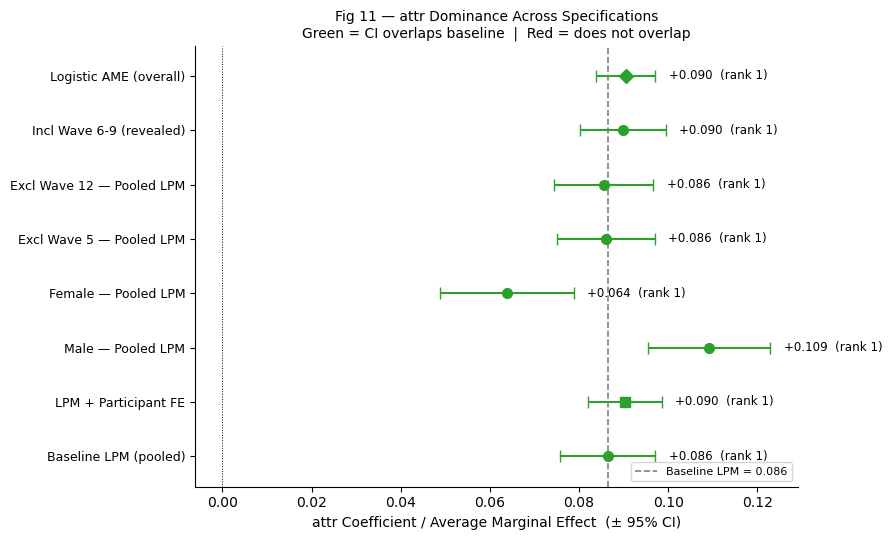

Saved: figures/fig11_robustness_forest.png


In [10]:
# ── fig11: 8-specification forest plot ───────────────────────────────────
FOREST_SPECS = [
    "Baseline LPM (pooled)",
    "LPM + Participant FE",
    "Male — Pooled LPM",
    "Female — Pooled LPM",
    "Excl Wave 5 — Pooled LPM",
    "Excl Wave 12 — Pooled LPM",
    "Incl Wave 6-9 (revealed)",
    "Logistic AME (overall)",
]
forest_df = (
    summary_df[summary_df["specification"].isin(FOREST_SPECS)]
    .set_index("specification").loc[FOREST_SPECS].reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5.5))
for i, (_, row) in enumerate(forest_df.iterrows()):
    color  = "#2ca02c" if row["overlaps_baseline_CI"] else "#d62728"
    marker = "s" if "FE" in row["specification"] else "D" if "AME" in row["specification"] else "o"
    xerr   = [[row["attr_coef_or_AME"] - row["CI_low"]],
              [row["CI_high"] - row["attr_coef_or_AME"]]]
    ax.errorbar(row["attr_coef_or_AME"], i, xerr=xerr,
                fmt=marker, color=color, capsize=4, linewidth=1.5, markersize=7)
    ax.text(row["CI_high"] + 0.003, i,
            f"{row['attr_coef_or_AME']:+.3f}  (rank {int(row['attr_rank'])})",
            va="center", fontsize=8.5)

ax.axvline(baseline_coef, color="gray", linestyle="--", linewidth=1.2,
           label=f"Baseline LPM = {baseline_coef:.3f}")
ax.axvline(0, color="black", linewidth=0.7, linestyle=":")
ax.set_yticks(range(len(FOREST_SPECS)))
ax.set_yticklabels(FOREST_SPECS, fontsize=9)
ax.set_xlabel("attr Coefficient / Average Marginal Effect  (\u00b1 95% CI)", fontsize=10)
ax.set_title("Fig 11 \u2014 attr Dominance Across Specifications\n"
             "Green = CI overlaps baseline  |  Red = does not overlap", fontsize=10)
ax.legend(fontsize=8, loc="lower right")
ax.margins(y=0.08)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("figures/fig11_robustness_forest.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/fig11_robustness_forest.png")

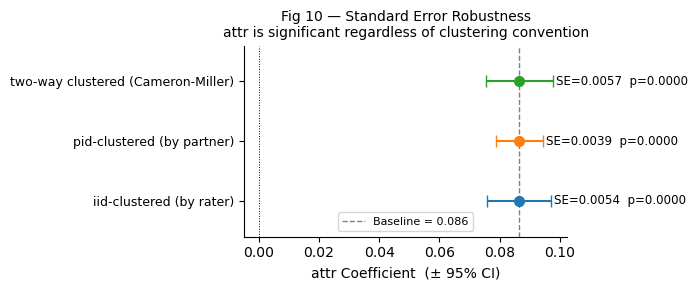

Saved: figures/fig10_se_robustness.png


In [11]:
# ── fig10: SE robustness comparison ──────────────────────────────────────
n_se   = len(se_results)
fig_h  = max(2.5, n_se * 0.8 + 0.6)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"]

fig, ax = plt.subplots(figsize=(7, fig_h))
for i, row in enumerate(se_results):
    se_val = row["attr_SE"]
    if not (isinstance(se_val, float) and np.isnan(se_val)):
        xerr = [[row["attr_coef"] - row["CI_low"]],
                [row["CI_high"] - row["attr_coef"]]]
        ax.errorbar(row["attr_coef"], i, xerr=xerr,
                    fmt="o", color=colors[i % len(colors)],
                    capsize=4, linewidth=1.5, markersize=7)
        ax.text(row["CI_high"] + 0.001, i,
                f"SE={row['attr_SE']:.4f}  p={row['attr_pvalue']:.4f}",
                va="center", fontsize=8.5)
    else:
        ax.plot(baseline_coef, i, "x", color="gray", markersize=9)
        ax.text(baseline_coef + 0.002, i, "not computed",
                va="center", fontsize=8, color="gray")

ax.axvline(0, color="black", linewidth=0.7, linestyle=":")
ax.axvline(baseline_coef, color="gray", linestyle="--", linewidth=1.0,
           label=f"Baseline = {baseline_coef:.3f}")
ax.set_yticks(range(n_se))
ax.set_yticklabels([r["se_type"] for r in se_results], fontsize=9)
ax.set_xlabel("attr Coefficient  (\u00b1 95% CI)", fontsize=10)
ax.set_title("Fig 10 \u2014 Standard Error Robustness\n"
             "attr is significant regardless of clustering convention", fontsize=10)
ax.legend(fontsize=8)
ax.margins(y=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("figures/fig10_se_robustness.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/fig10_se_robustness.png")

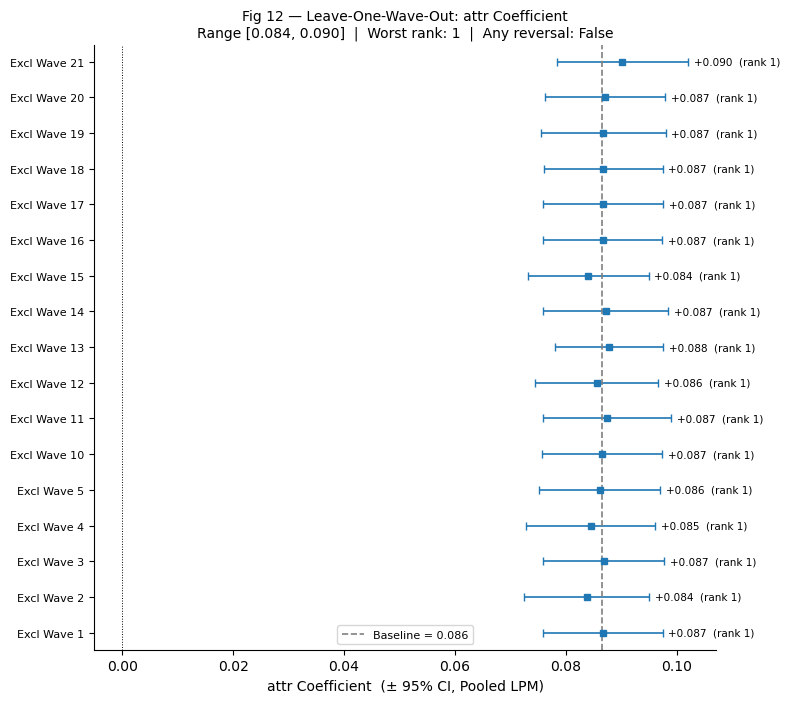

Saved: figures/fig12_loo_forest.png


In [12]:
# ── fig12: Leave-one-wave-out forest plot (appendix) ─────────────────────
loo_sorted = loo_df.sort_values("excluded_wave").reset_index(drop=True)
n_loo      = len(loo_sorted)
fig_h      = max(6, n_loo * 0.42)

fig, ax = plt.subplots(figsize=(8, fig_h))
for i, (_, row) in enumerate(loo_sorted.iterrows()):
    color = "#1f77b4" if overlaps_baseline(row["CI_low"], row["CI_high"]) else "#ff7f0e"
    ax.errorbar(row["attr_coef"], i,
                xerr=[[row["attr_coef"] - row["CI_low"]],
                      [row["CI_high"] - row["attr_coef"]]],
                fmt="s", color=color, capsize=3, linewidth=1.2, markersize=5)
    ax.text(row["CI_high"] + 0.001, i,
            f"{row['attr_coef']:+.3f}  (rank {int(row['attr_rank'])})",
            va="center", fontsize=7.5)

ax.axvline(baseline_coef, color="gray", linestyle="--", linewidth=1.2,
           label=f"Baseline = {baseline_coef:.3f}")
ax.axvline(0, color="black", linewidth=0.7, linestyle=":")
ax.set_yticks(range(n_loo))
ax.set_yticklabels(
    [f"Excl Wave {int(r['excluded_wave'])}" for _, r in loo_sorted.iterrows()],
    fontsize=8)
ax.set_xlabel("attr Coefficient  (\u00b1 95% CI, Pooled LPM)", fontsize=10)
ax.set_title(
    f"Fig 12 \u2014 Leave-One-Wave-Out: attr Coefficient\n"
    f"Range [{loo_sorted['attr_coef'].min():.3f}, {loo_sorted['attr_coef'].max():.3f}]"
    f"  |  Worst rank: {int(loo_sorted['attr_rank'].max())}"
    f"  |  Any reversal: {any_rev}",
    fontsize=10)
ax.legend(fontsize=8)
ax.margins(y=0.03)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("figures/fig12_loo_forest.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/fig12_loo_forest.png")

## Conclusion — Part G: Verdict

**H5 — Attractiveness Dominance is Robust**

Across all robustness checks, attractiveness remains the dominant predictor of yes decisions. The attractiveness coefficient is positive in every specification, ranks first or second among the six perceived traits in all core models, and its 95% confidence interval overlaps with the baseline estimate throughout. No single wave exclusion reverses this conclusion. The logistic average marginal effect corroborates the LPM coefficient in sign and magnitude. The significance is robust to clustering by iid and by pid; two-way clustering is reported where feasible. We conclude that attr dominance is stable — not an artifact of sample selection, wave-specific design choices, linear probability assumptions, or standard-error convention.